# Trabalho computacional 2
Aluna: Ana Júlia Brant Lobato 

Matrícula: 200056832

## Introdução e preparação

In [1]:
import torch
import torchvision
from torchvision import transforms
from d2l import torch as d2l
from torch import nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

In [2]:
class MNIST(d2l.DataModule):  #@save
    """The Fashion-MNIST dataset."""
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([transforms.Resize(resize),
                                    transforms.ToTensor()])
        self.train = torchvision.datasets.MNIST(
            root=self.root, train=True, transform=trans, download=True)
        self.val = torchvision.datasets.MNIST(
            root=self.root, train=False, transform=trans, download=True)

In [3]:
dataset = MNIST()
print(len(dataset.train), len(dataset.val))
print(dataset.train.data.shape)

60000 10000
torch.Size([60000, 28, 28])


In [4]:
@d2l.add_to_class(MNIST)  #@save
def get_dataloader(self, train):
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                       num_workers=self.num_workers)
    

In [5]:
X, y = next(iter(dataset.train_dataloader()))
print(X.shape, X.dtype, y.shape, y.dtype)

torch.Size([64, 1, 28, 28]) torch.float32 torch.Size([64]) torch.int64


#### Amostras de dígitos MNIST com seus respectivos rótulos


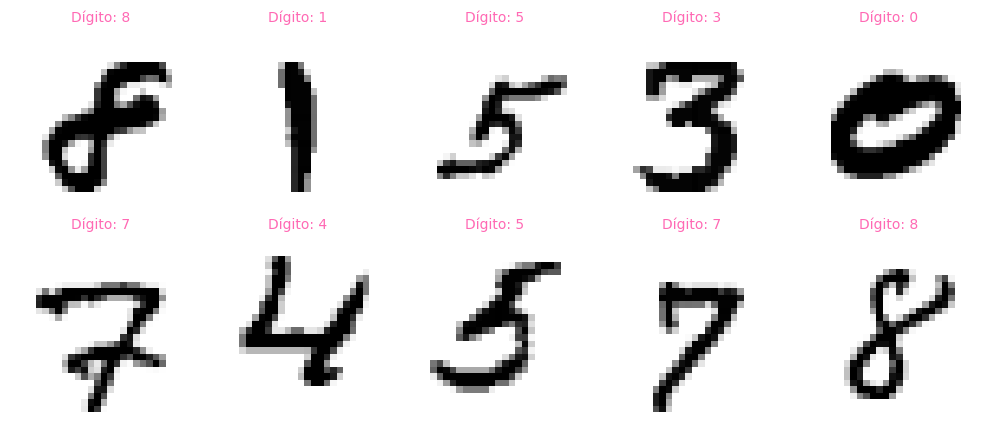

In [6]:
def plot_mnist_samples(data_module, num_rows=2, num_cols=5):

    X, y = next(iter(data_module.train_dataloader()))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(2 * num_cols, 2.2 * num_rows))
    axes = axes.flatten()
    
    for i in range(num_rows * num_cols):
      
        img = X[i].squeeze().numpy()
        label = y[i].item()
        
       
        axes[i].imshow(img, cmap='gray_r')
        axes[i].set_title(f"Dígito: {label}", fontsize=10, color='hotpink')
        axes[i].axis('off') 
        
    plt.tight_layout()
    plt.show()


plot_mnist_samples(dataset)

## Modelos e arquiteturas
### a) Perceptron com uma camada escondida

In [7]:
class MLP_sigmoid(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(), nn.LazyLinear(num_hiddens),
                                 nn.Sigmoid(), nn.LazyLinear(num_outputs))
    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), lr=self.lr)

In [8]:
def evaluate_accuracy(model, data_iter):
    model.eval()
    metric = d2l.Accumulator(2)
    with torch.no_grad():		
        for X, y in data_iter:
            metric.add(d2l.accuracy(model(X), y), y.numel())
    model.train()
    return metric[0] / metric[1]

In [9]:
def testes(classe_do_modelo, hparams, dataset, num_testes=3):
    acuracias = []

    for teste in range(num_testes):
        print(f"\n---Inicialização Aleatória {teste + 1}/{num_testes} ---")
        
        torch.manual_seed(42 + teste)

        model_novo = classe_do_modelo(**hparams)
        

        trainer = d2l.Trainer(max_epochs=10)     
        trainer.fit(model_novo, dataset)

        acc = evaluate_accuracy(model_novo, dataset.val_dataloader())
        acuracias.append(acc)
        print(f"Acurácia da rodada {teste + 1}: {acc * 100:.2f}%")

    acuracia_media = np.mean(acuracias)
    desvio_padrao = np.std(acuracias) 
    
    print("\n=========================================")
    print(f"Média das acurácias: {acuracia_media * 100:.2f}%")
    print(f"Desvio Padrão: {desvio_padrao * 100:.2f}%")
    print("=========================================")
    
    return acuracias

Acurácia da rodada 3: 94.27%

Média das acurácias: 94.35%
Desvio Padrão: 0.14%


[0.9423, 0.9454, 0.9427]

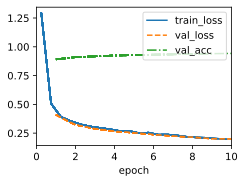

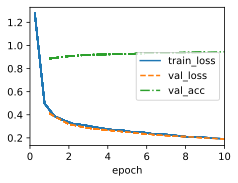

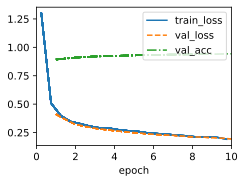

In [10]:
hparams = {
    'num_outputs': 10,
    'num_hiddens': 128,
    'lr': 0.1
}

testes(
    classe_do_modelo=MLP_sigmoid,
    hparams=hparams, 
    dataset=dataset, 
    num_testes = 3

)

Para o Perceptron com uma camada escondida, função de ativação sigmoide e otimização por descida de gradiente, obtivemos uma acurácia média de de 94,35% e um desvio padrão de 0,14%, indicando robustez da otimização por descida de gradiente.  

### b) Otimizador Adam

In [11]:
class MLP_Adam(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(), nn.LazyLinear(num_hiddens),
                                 nn.Sigmoid(), nn.LazyLinear(num_outputs))
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)
    

Acurácia da rodada 3: 97.51%

Média das acurácias: 97.49%
Desvio Padrão: 0.03%


[0.9745, 0.975, 0.9751]

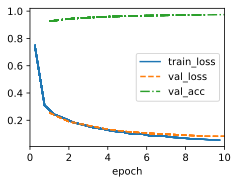

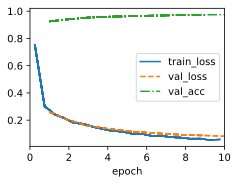

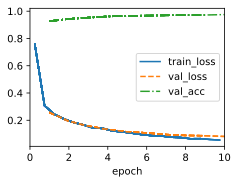

In [23]:
hparams_Adam = {
    'num_outputs': 10,
    'num_hiddens': 128,
    'lr': 0.001
}
testes(
    classe_do_modelo=MLP_Adam,
    hparams=hparams_Adam, 
    dataset=dataset, 
    num_testes = 3

)

Trocando o otimizador para Adam, a acurácia média sobe para 97.49% e o desvio padrão desce para 0.03%, indicando um melhor desempenho deste em relação ao otimizador SGD. 

### c) Função Relu

In [13]:
class MLP_relu(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(), nn.LazyLinear(num_hiddens),
                                 nn.ReLU(), nn.LazyLinear(num_outputs))
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

Acurácia da rodada 3: 97.78%

Média das acurácias: 97.70%
Desvio Padrão: 0.08%


[0.9774, 0.9759, 0.9778]

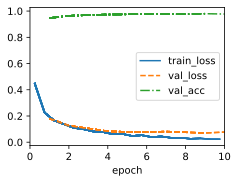

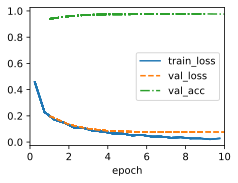

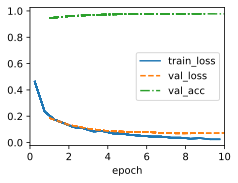

In [24]:
testes(
    classe_do_modelo=MLP_relu,
    hparams=hparams_Adam, 
    dataset=dataset, 
    num_testes = 3

)

Substituindo a função de ativação para ReLU, obtivemos uma acurácia média de 97.70% e um desvio padrão de 0.08%, bastante similares à anterior, indicando desempenho similar para as funções de ativação ReLu e Sigmoide. 

### d) Redes maiores

Uma camada escondida com 256 neurônios:

Acurácia da rodada 3: 97.93%

Média das acurácias: 97.98%
Desvio Padrão: 0.05%


[0.9796, 0.9804, 0.9793]

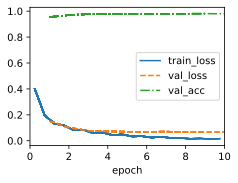

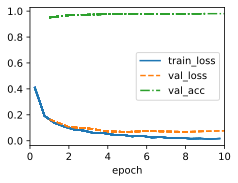

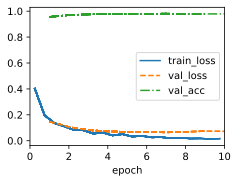

In [25]:
hparams_2 = {
    'num_outputs': 10,
    'num_hiddens': 256,
    'lr': 0.001
}

testes(
    classe_do_modelo=MLP_relu,
    hparams=hparams_2, 
    dataset=dataset, 
    num_testes = 3

)

Dobrando o número de neurônios, obtivemos uma acurácia média levemente maior, agora de 97.98% e um desvio padrão de 0.05%.

Uma rede com duas camadas escondidas:

In [16]:
class MLP_deep(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(), nn.LazyLinear(num_hiddens_1),
                                 nn.ReLU(), nn.LazyLinear(num_hiddens_2),
                                 nn.ReLU(), nn.LazyLinear(num_outputs))
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

Acurácia da rodada 3: 98.22%

Média das acurácias: 97.88%
Desvio Padrão: 0.28%


[0.9789, 0.9753, 0.9822]

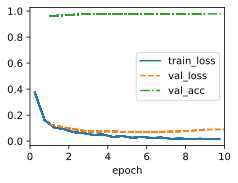

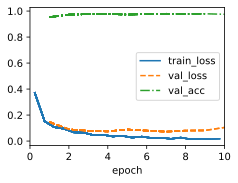

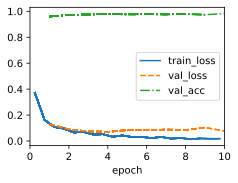

In [26]:
hparams_deep = {
    'num_outputs': 10,
    'num_hiddens_1': 256,
    'num_hiddens_2' : 256,
    'lr': 0.001
}

testes(
    classe_do_modelo=MLP_deep,
    hparams=hparams_deep, 
    dataset=dataset, 
    num_testes = 3

)

Adicionando mais uma camada escondida, obtivemos uma acurácia média de 97.88% e um desvio padrão de 0.28% similar ao caso anterior, mas com uma sensibilidade à entrada levemente maior. 

## Visualização

In [18]:
def visualizar_erros_mnist(model, dataset, num_exemplos=10):
    model.eval()

    imagem = []
    rotulo = []
    predicao = []
    
    with torch.no_grad():
        for X, y in dataset.val_dataloader():
            outputs = model(X)
            preds = torch.argmax(outputs, axis=1)

            indices_erros = (preds != y).nonzero(as_tuple=True)[0]

            if len(indices_erros) == 0:
                continue
            for idx in indices_erros:
                if len(imagem) >= num_exemplos:
                    break
                imagem.append(X[idx])
                rotulo.append(y[idx].item())
                predicao.append(preds[idx].item())

            if len(imagem) >= num_exemplos:
                break


    print(f"Total de erros capturados para exibição: {len(imagem)}")

    num_cols = 5
    num_rows = (len(imagem) + num_cols - 1) // num_cols
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(2 * num_cols, 2.2 * num_rows))

    if len(imagem) == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    for i in range(len(axes)):
        if i < len(imagem):
            img = imagem[i].squeeze().numpy()
            
           
            axes[i].imshow(img, cmap='gray_r')
            axes[i].set_title(f"Real: {rotulo[i]}\nPredito: {predicao[i]}", 
                              fontsize=10, color='hotpink')
        axes[i].axis('off') 
        
    plt.tight_layout()
    plt.show()

Total de erros capturados para exibição: 10


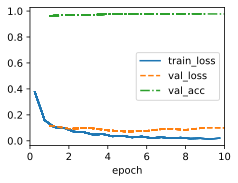

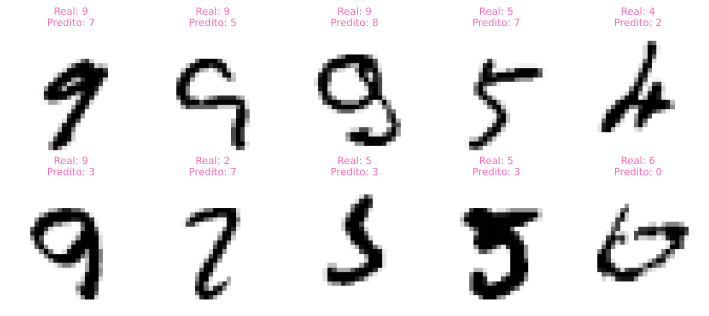

In [32]:
melhor_modelo = MLP_deep(num_outputs=10, num_hiddens_1=256, num_hiddens_2=256, lr=0.001)

trainer_final = d2l.Trainer(max_epochs=10)
trainer_final.fit(melhor_modelo, dataset)


visualizar_erros_mnist(melhor_modelo, dataset, num_exemplos=10)

Fazendo uma análise visual dos resultados, não foi possível classificar todos os números corretamente, como, por exemplo, os dois últimos casos. Se a classificação fosse feita por um humano, o resultado também não seria 100% de acurácia, mas poderia visualizar algumas nuances que o modelo não conseguiu observar. 

## Matriz de confusão

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

In [21]:
def matriz_confusao(model, dataset):
    model.eval()
    
    reais_tot = []
    pred_tot = []

    with torch.no_grad():
        for X, y in dataset.val_dataloader():
            outputs = model(X)
            preds = torch.argmax(outputs, axis=1)

            reais_tot.extend(y.cpu().numpy())
            pred_tot.extend(preds.cpu().numpy())
    cm = confusion_matrix(reais_tot, pred_tot)

    fig, ax = plt.subplots(figsize=(8, 8))
    
    ConfusionMatrixDisplay.from_predictions(
        reais_tot, 
        pred_tot,
        display_labels=[str(i) for i in range(10)],
        cmap=plt.cm.RdPu,
        values_format='d',
        ax=ax 
    )

    plt.title("Matriz de Confusão - Validação MNIST", fontsize=14, fontweight='bold')
    plt.xlabel("Classe Predita", fontsize=12)
    plt.ylabel("Classe Real (Rótulo Esperado)", fontsize=12)
    plt.show()
    
        
    

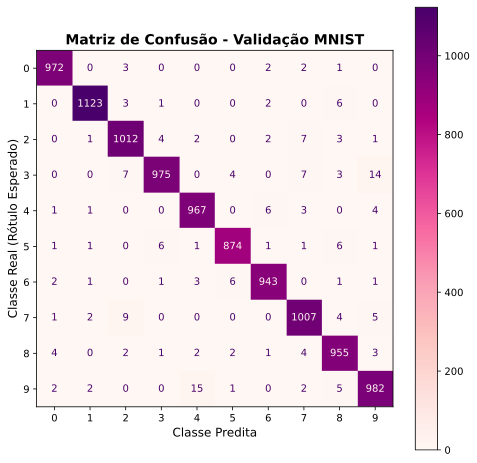

In [31]:
matriz = matriz_confusao(melhor_modelo, dataset)

Observando a matriz de confusão acima, percebemos que as confusões mais comuns são classificar 3 como 9 e classificar 9 como 4. Esses erros, a meu ver, fazem sentido tendo em vista o formato dos números. 